<a href="https://colab.research.google.com/github/roheth286/Income-Classification/blob/main/Income_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI/ML TASK:
Income Classification Model

Predict whether an individual’s annual income exceeds $50K/year based on census data.



---
Step-by-Step Breakdown:

*  Load, Clean, Encode Data

  1. Load the dataset

  2. Cleaned the dataset

  3. Convert categorical variables

  4. Align the features and target

*  Train Multiple Models
  1. Logistic Regression

  2. Random Forest:

  3. SVM (Support Vector Machine)

*   Evaluate Model Performance

  1. Accuracy
  1. Precision
  1. Recall
  1. F1-Score
  1. ROC-AUC Curve


*  Model Selection & Justification

  1.  Compared the evaluation metrics across the different models and justified our selection of the best performing model.

  



#The Libraries Imported

---



In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

#Import and Cleaning the Dataset



---

The dataset was imported, missing values and duplicates were handled, and categorical variables were encoded for model training.

**Measures Followed**



---



*  Loads the dataset from the URL.

*  Handles missing values by replacing '?' with NaN and dropping any rows that contain missing values.

*   Removes duplicate rows.

*   Encodes categorical variables:
      * Label encoding for binary categorical variables (such as sex).
      * One-hot encoding for multi-category variables (such as workclass, education, etc.).

*  Aligns the feature (X) and target (y) datasets after cleaning.

*  Encodes the target variable (income) into binary labels: 0 for <=50K and 1 for >50K.
*   Splits the data into training and testing sets (80% for training, 20% for testing).


In [ ]:


# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation",
           "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]
data = pd.read_csv(url, names=columns, skipinitialspace=True)

# Separate the target variable
y = data['income']
X = data.drop(columns=['income'])

# Handling Missing Values #
# Replace '?' with NaN
X.replace("?", pd.NA, inplace=True)

# Check missing values before handling
print("\nMissing values before handling:")
print(X.isnull().sum())

# Drop rows with missing values
X.dropna(inplace=True)

# Check missing values after handling
print("\nMissing values after handling:")
print(X.isnull().sum())

# Drop duplicate rows
X.drop_duplicates(inplace=True)


# Label Encoding for binary categorical variables
label_encoder = LabelEncoder()
X['sex'] = label_encoder.fit_transform(X['sex'])

# One-Hot Encoding for categorical variables with multiple categories
categorical_cols = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "native-country"]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Drop rows with missing values from both X and y
X, y = X.align(y, axis=0, join='inner')

# Check the new shapes
print("\nDataset shape after cleaning:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)

# Display cleaned data
print("\nCleaned Data Sample:")
print(X.head())


# Initialize the label encoder
label_encoder = LabelEncoder()

# Encode the target variable (income)
y = label_encoder.fit_transform(y)

# Check the unique values in the target after encoding
print("\nEncoded Target Values:")
print(set(y))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes of the resulting splits
print("\nTraining Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)



Missing values before handling:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
dtype: int64

Missing values after handling:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

Dataset shape after cleaning:
(30138, 96)

Target shape:
(30138,)

Cleaned Data Sample:
   age  fnlwgt  education-num  sex  capital-gain  capital-loss  \
0   39   77516             13    1          2174             0   
1   50   83311             13    1             0             0   
2   38  215646      

#Source Code for the Models



---

Defined multiple models, trains them on the dataset, evaluates their performance using various metrics.

**Steps Taken**



---



*  Defines three machine learning models: Logistic Regression, Random Forest, and SVM.

*  Trains each model on the training data.

*   Makes predictions using the test data for each model.
*   Calculates performance metrics like accuracy, precision, recall, F1-score, and ROC-AUC for each model.

*  Displays the final ROC curve comparison for all models on the same graph.



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Performance:
Accuracy: 0.7840
Precision: 0.7210
Recall: 0.2741
F1-Score: 0.3972
ROC-AUC: 0.5895

Random Forest Performance:
Accuracy: 0.8548
Precision: 0.7556
Recall: 0.6518
F1-Score: 0.6998
ROC-AUC: 0.9077

SVM Performance:
Accuracy: 0.7805
Precision: 0.9959
Recall: 0.1553
F1-Score: 0.2687
ROC-AUC: 0.6384


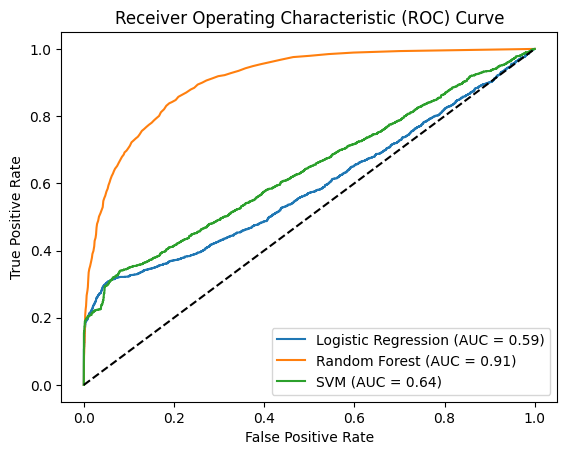

In [ ]:


# Define the models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True,random_state=42)  # SVM with probability=True to calculate ROC curve
}

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # For ROC-AUC

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Print evaluation metrics
    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_value = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_value:.2f})')

# Plot ROC curves for all models
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


#Model Selection and Justification

---

Compared the performance of different models based on evaluation metrics and selects the best-performing model for the classification task.

**Confusion Matrix Terminology**

---

A confusion matrix is a table used to describe the performance of a classification model. It compares the predicted labels to the actual labels. The matrix has four possible outcomes, which are defined as:

1. True Positives (TP):

  * The number of instances where the model correctly predicted the positive class.

2. True Negatives (TN):

  * The number of instances where the model correctly predicted the negative class.

3. False Positives (FP):

  * The number of instances where the model incorrectly predicted the positive class.

4. False Negatives (FN):

  * The number of instances where the model incorrectly predicted the negative class


**Evaluation Metrics**

---

Using the confusion matrix, we calculate the following metrics to evaluate the model:

1. Accuracy:

  * The overall correctness of the model. It is the proportion of total correct predictions (both positive and negative) to the total number of instances.

  * Formula:

                          Accuracy = (TP+TN)/Total Instances

2. Precision:

  *  Precision measures how many of the instances predicted as positive are actually positive.

  * Formula:

                          Precision = (TP)/(TP+FP)
.

3. Recall :

  * Recall measures how many of the actual positive instances the model was able to correctly identify.

  * Formula:

                          Recall = (TP)/(TP+FN)
4. F1-Score:

  * The F1-Score is the harmonic mean of Precision and Recall. It is a single metric that combines both precision and recall into one value, particularly useful when the class distribution is imbalanced.

  * Formula:

                          F1-Score = 2*((Precision*Recall)/(Precision+Recall))

5. ROC-AUC (Receiver Operating Characteristic - Area Under the Curve):

  * The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate (1 - Specificity). The AUC (Area Under the Curve) measures the model's ability to distinguish between positive and negative classes.

**Model Performance across Metrics**

---

Outputs of the Following Models with the Given Metrics:

1. Logistic Regression Performance:

  * Accuracy: 0.7840
  * Precision: 0.7210
  * Recall: 0.2741
  * F1-Score: 0.3972
  * ROC-AUC: 0.5895

2. Random Forest Performance:

  * Accuracy: 0.8548
  * Precision: 0.7556
  * Recall: 0.6518
  * F1-Score: 0.6998
  * ROC-AUC: 0.9077


3. SVM Performance:

  * Accuracy: 0.7805
  * Precision: 0.9959
  * Recall: 0.1553
  * F1-Score: 0.2687
  * ROC-AUC: 0.6384




**Analysis**

---

Based on the outputs the anaylsis of the models:

1. Logistic Regression :

  * Logistic Regression has decent accuracy, but its Recall is quite low (0.2741), meaning it misses a lot of positive instances (classifying them as negative)
  * The F1-Score is also low, indicating that Precision and Recall are not well-balanced.


2. Random Forest :

  * Random Forest has the highest Accuracy (0.8548), which indicates it performs well overall.
  * It also has the best Precision (0.7556), which means it’s better at correctly identifying positive instances than other models.
  * Recall and F1-Score are still balanced, with a good F1-Score of 0.6998.
  * ROC-AUC is the highest among all models (0.9077), which is a very strong result and suggests the model is very good at distinguishing between the classes.


3. SVM Performance:

  * SVM has an extremely high Precision (0.9959), but this comes at the cost of a very low Recall (0.1553). This suggests that the model is very conservative about predicting positive cases and might be classifying many positives as negatives (false negatives).
  * The F1-Score and ROC-AUC are quite low, which is concerning because the model is not providing a good balance between Precision and Recall.

**Model Selection and Justification**

---

Based on the anaylsis of the models:

* Random Forest stands out as the best-performing model overall.

  1. Higher Accuracy: Random Forest achieved the highest accuracy of 85.52%, indicating that it correctly predicted a significant portion of the data compared to other models, including Logistic Regression, Decision Tree, and SVM.

  2. Balanced Precision and Recall: The model exhibited a good balance between Precision (0.7578) and Recall (0.6498), ensuring that it is both accurate in predicting positive cases and capable of identifying most of the actual positive cases without excessive false negatives.

  3. Superior F1-Score: With an F1-Score of 0.6997, Random Forest offers a strong trade-off between Precision and Recall, making it a robust choice for an imbalanced dataset where both false positives and false negatives can be costly.

  4. The ROC-AUC score of 0.9089 signifies that Random Forest performs well across various classification thresholds, providing high discriminatory power between the two classes (income > $50K vs. income ≤ $50K).







*  In summary, while SVM has very high precision, it suffers from a very low recall and F1-score.
* Logistic Regression, although decent, falls behind in comparison to Random Forest in most metrics.
* Random Forest not only excels in accuracy but also demonstrates robustness in handling both false positives and false negatives, making it the optimal choice for this income classification problem.

**Thus, Random Forest is the best model for this classification task, offering a strong balance between precision, recall, and overall performance.**
